<a href="https://colab.research.google.com/github/tyracheng/machine-learning-projects-2024/blob/main/Iris_dataset_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Refining Pytorch Skills

Built a simple neural network using iris dataset https://archive.ics.uci.edu/dataset/53/iris

This is my first time applying both computer science and statistical analysis to create a basic classification model. I taught myself using a variety of online resources.
- Tyra Cheng

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
#create a model class that inherits the nn.module
class Model (nn.Module):
  #input layer (4 features of the flower)
  def __init__ (self, in_features = 4, h1 = 8, h2 = 9, out_features = 3):
    super().__init__() #instantiate our nn.Module
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x


In [3]:
#pick a manual seed for randomization
torch.manual_seed(32)

#create an instance of the model class
model = Model()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)


my_df.tail()

,sepal.length,sepal.width,petal.length,petal.width,variety
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


In [6]:
# change last column from strings to integers
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)
my_df

/tmp/ipykernel_1956/1645763137.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [7]:
# train test and split things
# we want to drop the last column
X = my_df.drop('variety', axis = 1)
y = my_df['variety']

In [8]:
# Convert these to numpy arrays
X = X.values
y = y.values

In [9]:
from sklearn.model_selection import train_test_split
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 32)

In [10]:
# convert x features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

# convert y labels to tensors long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [11]:
# set criterion of model to measure the error, how far off the predictions are from
criterion = nn.CrossEntropyLoss()

#choose Adan optimizer, learning rate = lr (if error doesn't go down afer a bunch of iterations, we need to lower our lr)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)



In [12]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [13]:
# Train our model!
# Epochs? (one run thru all the training data in our network)
epochs = 100
losses = []
for i in range(epochs):
  # Go forward and get a prediction
  y_pred = model.forward(X_train) # Get predicted results

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train) # predicted values vs the y_train

  # Keep Track of our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it back
  # thru the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch: 0 and loss: 1.1699321269989014
Epoch: 10 and loss: 0.9570867419242859
Epoch: 20 and loss: 0.7980871796607971
Epoch: 30 and loss: 0.6327950358390808
Epoch: 40 and loss: 0.43861737847328186
Epoch: 50 and loss: 0.290453165769577
Epoch: 60 and loss: 0.17780695855617523
Epoch: 70 and loss: 0.11584118008613586
Epoch: 80 and loss: 0.0893637090921402
Epoch: 90 and loss: 0.07752915471792221


Text(0.5, 0, 'Epoch')

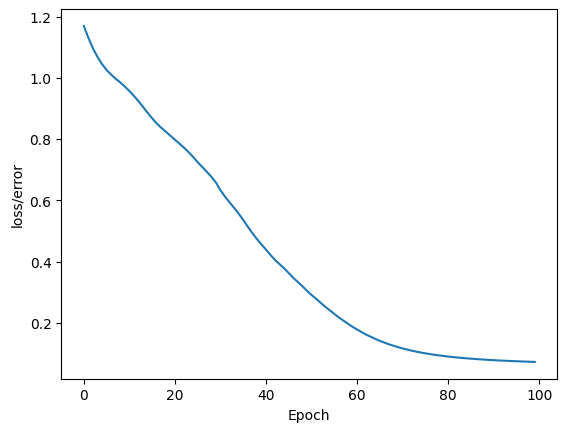

In [14]:
# graph it
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

In [15]:
#evaluate test data set on nn

with torch.no_grad(): #turn off backpropagation
  y_eval = model.forward(X_test) #X_test are features from our test set, y_eval will be predictions
  loss = criterion(y_eval, y_test) # find the loss or error
loss

tensor(0.0538)

In [16]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      x = 'Setosa'
    elif y_test[i] == 1:
      x = 'Versicolor'
    else:
      x = 'Virginica'
    #Will tell us what type of flower our network thinks it is
    print(f'{i+1}.) {str(y_val)} \t {x} \t {y_val.argmax().item()}')

    #correct or not
    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'Accuracy: {correct}/{len(X_test)}')

1.) tensor([-3.3646,  3.9392,  0.3720]) 	 Versicolor 	 1
2.) tensor([  7.5572,   1.1015, -11.3347]) 	 Setosa 	 0
3.) tensor([  6.5957,   1.5027, -10.4091]) 	 Setosa 	 0
4.) tensor([-3.3331,  4.2594,  0.0623]) 	 Versicolor 	 1
5.) tensor([-7.3782,  2.8087,  5.1605]) 	 Virginica 	 2
6.) tensor([-7.3760,  3.9013,  4.2826]) 	 Virginica 	 2
7.) tensor([  6.1971,   1.6470, -10.0047]) 	 Setosa 	 0
8.) tensor([  6.6383,   1.4348, -10.4031]) 	 Setosa 	 0
9.) tensor([-2.6753,  4.3091, -0.6392]) 	 Versicolor 	 1
10.) tensor([  7.1875,   1.3812, -11.0965]) 	 Setosa 	 0
11.) tensor([-3.8318,  4.4027,  0.5246]) 	 Versicolor 	 1
12.) tensor([-8.6807,  1.9994,  6.8923]) 	 Virginica 	 2
13.) tensor([-2.0678,  3.8200, -0.7571]) 	 Versicolor 	 1
14.) tensor([-1.0768,  4.3741, -2.2838]) 	 Versicolor 	 1
15.) tensor([-7.4965,  2.6207,  5.3287]) 	 Virginica 	 2
16.) tensor([-8.6136,  1.5508,  7.1186]) 	 Virginica 	 2
17.) tensor([-3.7761,  3.6462,  0.9487]) 	 Versicolor 	 1
18.) tensor([-6.7608,  2.7754,  4

In [17]:
#evaluate new data on the network
new_iris = torch.tensor([5.1, 3.5, 1.4, 0.2])
with torch.no_grad():
  print(model.forward(new_iris))

tensor([  7.4295,   1.3068, -11.3544])
